In [1]:
import math
import random
from dataclasses import dataclass
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device


device(type='cuda')

In [2]:
@dataclass
class CFG:
    data_root: str = "./data"
    batch_size: int = 128
    lr: float = 1e-3
    epochs: int = 20  
    latent_dim: int = 16  # 隐变量维度
    beta: float = 1.0     # KL 最终权重（=1 即标准VAE）
    beta_warmup_epochs: int = 5  # 前N个epoch线性warm-up到beta
    num_workers: int = 2
    pin_memory: bool = True

cfg = CFG()


## 1) 数据加载：筛选 MNIST 中数字0

In [3]:
transform = transforms.ToTensor()  # 输出为 [0,1]

train_full = datasets.MNIST(root=cfg.data_root, train=True, download=True, transform=transform)
test_full  = datasets.MNIST(root=cfg.data_root, train=False, download=True, transform=transform)

def filter_digit(dataset, digit=0):
    # MNIST targets: torch tensor
    targets = dataset.targets
    idx = (targets == digit).nonzero(as_tuple=False).squeeze(1)
    return Subset(dataset, idx.tolist())

train_0 = filter_digit(train_full, 0)
test_0  = filter_digit(test_full, 0)

len(train_0), len(test_0)


(5923, 980)

In [4]:
train_loader = DataLoader(
    train_0,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=cfg.num_workers,
    pin_memory=cfg.pin_memory and (device.type == 'cuda'),
)

test_loader = DataLoader(
    test_0,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    pin_memory=cfg.pin_memory and (device.type == 'cuda'),
)

xb, yb = next(iter(train_loader))
xb.shape, yb.unique()


(torch.Size([128, 1, 28, 28]), tensor([0]))

## 2) 定义 VAE（Encoder / Reparameterize / Decoder）

- 输入：`(B,1,28,28)`
- Encoder 输出：`mu, logvar`，shape `(B, latent_dim)`
- Decoder 输出：`recon`，shape `(B,1,28,28)`，范围 `[0,1]`

In [ ]:
class Encoder(nn.Module):
    def __init__(self, latent_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            # 卷积层1: 输入1通道(灰度图), 输出32通道, 尺寸减半 (28x28 -> 14x14)
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            # 卷积层2: 输出64通道, 尺寸再次减半 (14x14 -> 7x7)
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.Flatten(),  # 展平: 64 * 7 * 7
        )
        # 两个全连接层分别预测均值(mu)和对数方差(logvar)
        self.fc_mu = nn.Linear(in_features=64 * 7 * 7, out_features=latent_dim)
        self.fc_logvar = nn.Linear(in_features=64 * 7 * 7, out_features=latent_dim)

    def forward(self, x):
        h = self.net(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar


class Decoder(nn.Module):
    def __init__(self, latent_dim: int):
        super().__init__()
        # 将隐变量映射回特征图所需的维度
        self.fc = nn.Linear(in_features=latent_dim, out_features=64 * 7 * 7)
        self.net = nn.Sequential(
            # 转置卷积1: 上采样 (7x7 -> 14x14)
            nn.ConvTranspose2d(in_channels=64, out_channels=32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            # 转置卷积2: 上采样 (14x14 -> 28x28), 恢复到原图尺寸
            nn.ConvTranspose2d(in_channels=32, out_channels=1, kernel_size=4, stride=2, padding=1),
        )

    def forward(self, z):
        # 先通过全连接层，再reshape成特征图形状 (B, 64, 7, 7)
        h = self.fc(z).view(z.size(0), 64, 7, 7)
        logits = self.net(h)
        return logits  # 返回未经过sigmoid的logits，方便计算BCEWithLogitsLoss


class VAE(nn.Module):
    def __init__(self, latent_dim: int):
        super().__init__()
        self.encoder = Encoder(latent_dim=latent_dim)
        self.decoder = Decoder(latent_dim=latent_dim)

    @staticmethod
    def reparameterize(mu, logvar):
        # 重参数化技巧: z = mu + sigma * epsilon
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + std * eps

    def forward(self, x):
        # 1. 编码获取分布参数
        mu, logvar = self.encoder(x)
        # 2. 采样隐变量
        z = self.reparameterize(mu, logvar)
        # 3. 解码重构
        x_logits = self.decoder(z)
        return x_logits, mu, logvar


model = VAE(latent_dim=cfg.latent_dim).to(device)
sum(p.numel() for p in model.parameters())


220385

## 3) 损失函数：重构损失 + KL

- 重构损失：`BCE(x_recon, x)`，按像素求和再对 batch 取均值
- KL：`-0.5 * sum(1 + logvar - mu^2 - exp(logvar))`，对 batch 取均值

In [6]:
def vae_losses(x, x_logits, mu, logvar, beta: float = 1.0):
    # recon: sum over pixels, mean over batch
    recon = F.binary_cross_entropy_with_logits(x_logits, x, reduction='none')
    recon = recon.flatten(1).sum(dim=1).mean()
    # KL: mean over batch
    kl_per_sample = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1)
    kl = kl_per_sample.mean()

    loss = recon + beta * kl
    return loss, recon, kl


## 4) 训练与评估循环

记录每个 epoch：
- `train_recon`, `train_kl`, `train_total`
- `test_recon`（测试集重构能力）

In [ ]:
# 定义优化器
optimizer = torch.optim.Adam(model.parameters(), lr=cfg.lr)

# 用于记录训练过程中的各项损失指标
history = {
    'train_total': [],
    'train_recon': [],
    'train_kl': [],
    'test_recon': [],
}




@torch.no_grad()
def run_epoch_test(model, loader, epoch: int):
    """测试/验证一个 epoch"""
    model.eval()
    tot_recon = 0.0
    n = 0
    beta = get_beta(epoch)
    
    for x, _ in loader:
        x = x.to(device)
        x_logits, mu, logvar = model(x)
        # 验证阶段主要关注重构误差
        _, recon, _ = vae_losses(x, x_logits, mu, logvar, beta=beta)
        
        bs = x.size(0)
        tot_recon += recon.item() * bs
        n += bs
    return tot_recon / n

# 主训练循环
for epoch in range(1, cfg.epochs + 1):
    # 执行训练和测试
    train_total, train_recon, train_kl, beta = run_epoch_train(model, train_loader, epoch)
    test_recon = run_epoch_test(model, test_loader, epoch)

    # 记录历史数据以便后续绘图
    history['train_total'].append(train_total)
    history['train_recon'].append(train_recon)
    history['train_kl'].append(train_kl)
    history['test_recon'].append(test_recon)

    # 打印当前 Epoch 的各项指标
    print(
        f"Epoch {epoch:02d}/{cfg.epochs} | "
        f"beta={beta:.2f} | "
        f"train_total={train_total:>6.2f} recon={train_recon:>6.2f} kl={train_kl:>5.2f} | "
        f"test_recon={test_recon:>6.2f} | "
    )

Epoch 01/20 | beta=0.20 | train_total=304.85 recon=287.28 kl=87.84 | test_recon=191.49 | 
Epoch 02/20 | beta=0.40 | train_total=175.39 recon=161.75 kl=34.10 | test_recon=134.28 | 
Epoch 03/20 | beta=0.60 | train_total=140.60 recon=124.41 kl=26.98 | test_recon=111.96 | 
Epoch 04/20 | beta=0.80 | train_total=129.69 recon=110.56 kl=23.91 | test_recon=102.81 | 
Epoch 05/20 | beta=1.00 | train_total=126.02 recon=103.59 kl=22.43 | test_recon= 98.38 | 
Epoch 06/20 | beta=1.00 | train_total=121.52 recon= 99.19 kl=22.33 | test_recon= 95.87 | 
Epoch 07/20 | beta=1.00 | train_total=118.61 recon= 96.26 kl=22.34 | test_recon= 94.95 | 
Epoch 08/20 | beta=1.00 | train_total=117.29 recon= 94.95 kl=22.34 | test_recon= 92.26 | 
Epoch 09/20 | beta=1.00 | train_total=115.80 recon= 93.38 kl=22.42 | test_recon= 90.86 | 
Epoch 10/20 | beta=1.00 | train_total=114.41 recon= 92.08 kl=22.34 | test_recon= 90.37 | 
Epoch 11/20 | beta=1.00 | train_total=113.64 recon= 91.27 kl=22.36 | test_recon= 91.94 | 
Epoch 12/2

## 5) 损失曲线可视化

- 训练集重构损失与 KL
- 测试集重构损失

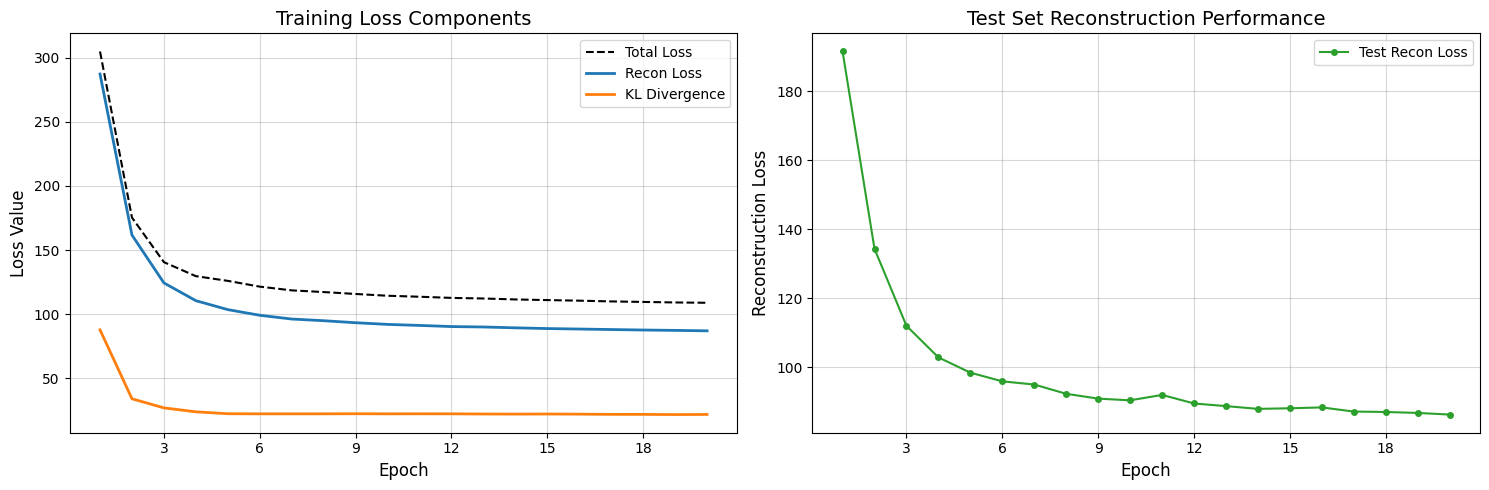

In [8]:
from matplotlib.ticker import MaxNLocator

epochs = np.arange(1, cfg.epochs + 1)

plt.figure(figsize=(15, 5))

# Subplot 1: Train Losses (Total, Recon, KL)
ax1 = plt.subplot(1, 2, 1)
ax1.plot(epochs, history['train_total'], label='Total Loss', color='black', linestyle='--', linewidth=1.5)
ax1.plot(epochs, history['train_recon'], label='Recon Loss', color='tab:blue', linewidth=2)
ax1.plot(epochs, history['train_kl'], label='KL Divergence', color='tab:orange', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss Value', fontsize=12)
ax1.set_title('Training Loss Components', fontsize=14)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.5)
ax1.xaxis.set_major_locator(MaxNLocator(integer=True)) # Force integer ticks

# Subplot 2: Test Reconstruction Loss
ax2 = plt.subplot(1, 2, 2)
ax2.plot(epochs, history['test_recon'], label='Test Recon Loss', color='tab:green', marker='o', markersize=4)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Reconstruction Loss', fontsize=12)
ax2.set_title('Test Set Reconstruction Performance', fontsize=14)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.5)
ax2.xaxis.set_major_locator(MaxNLocator(integer=True)) # Force integer ticks

plt.tight_layout()
plt.show()


## 6) 重构效果展示（训练/测试各取少量样本）

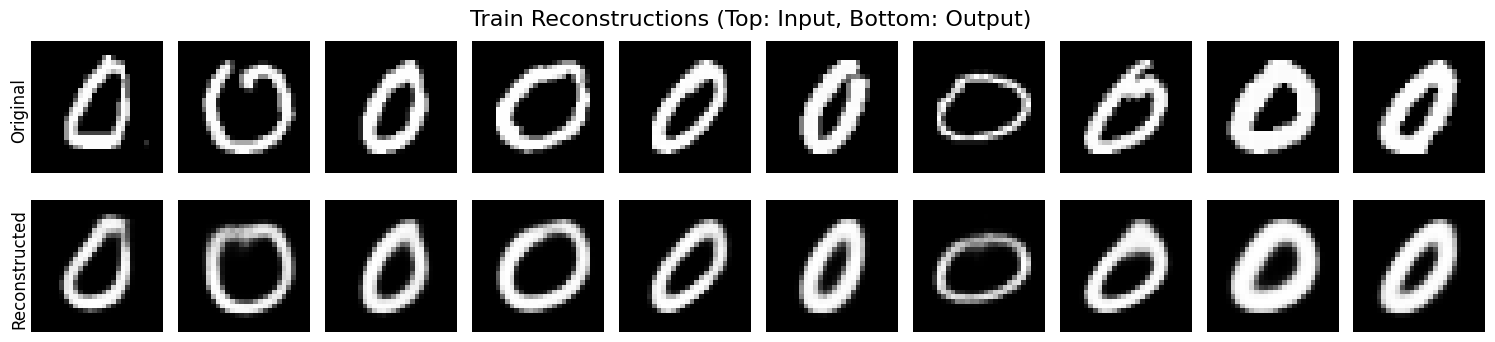

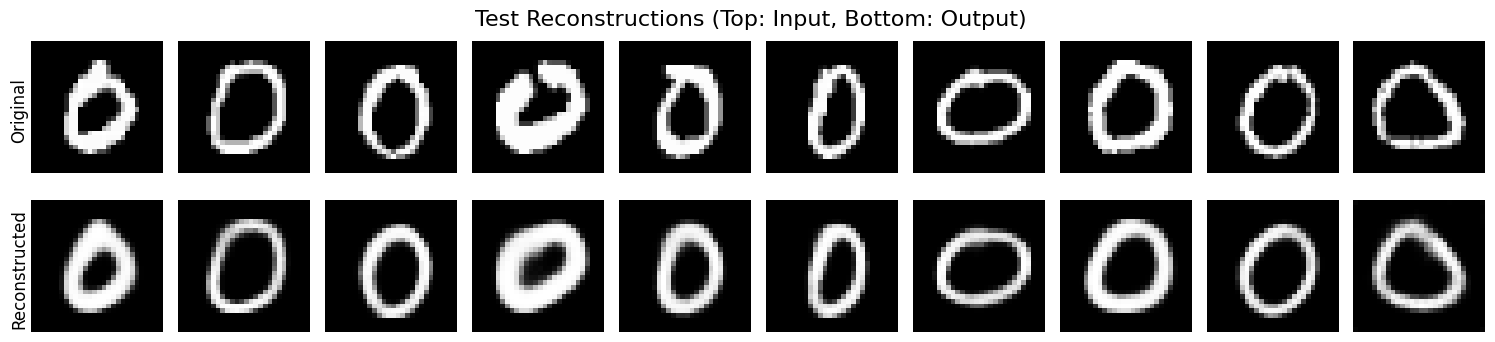

In [9]:
@torch.no_grad()
def show_reconstructions(model, loader, title: str, n: int = 8):
    model.eval()
    x, _ = next(iter(loader))
    x = x[:n].to(device)

    x_logits, _, _ = model(x)
    x_recon = torch.sigmoid(x_logits)

    x = x.cpu().numpy()
    x_recon = x_recon.cpu().numpy()

    fig, axes = plt.subplots(2, n, figsize=(1.5 * n, 4))
    for i in range(n):
        ax_orig = axes[0, i]
        ax_orig.imshow(x[i, 0], cmap='gray')
        ax_orig.axis('off')

        ax_recon = axes[1, i]
        ax_recon.imshow(x_recon[i, 0], cmap='gray')
        ax_recon.axis('off')

    axes[0, 0].text(-5, 14, "Original", fontsize=12, va='center', rotation=90)
    axes[1, 0].text(-5, 14, "Reconstructed", fontsize=12, va='center', rotation=90)

    plt.suptitle(title, fontsize=16, y=0.9)
    plt.tight_layout()
    plt.show()

show_reconstructions(model, train_loader, title='Train Reconstructions (Top: Input, Bottom: Output)', n=10)
show_reconstructions(model, test_loader, title='Test Reconstructions (Top: Input, Bottom: Output)', n=10)


## 7) 潜空间随机采样生成新数字0图像

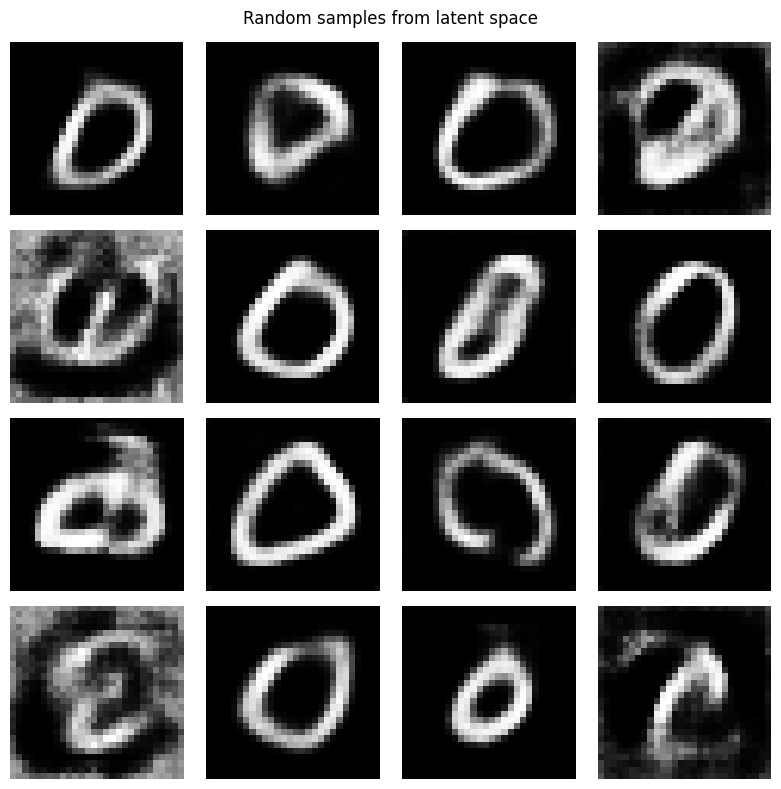

In [10]:
@torch.no_grad()
def sample_and_generate(model, latent_dim: int, n: int = 16):
    model.eval()
    z = torch.randn(n, latent_dim, device=device)
    x_logits = model.decoder(z)
    x_gen = torch.sigmoid(x_logits).cpu().numpy()

    cols = int(math.sqrt(n))
    rows = int(math.ceil(n / cols))
    plt.figure(figsize=(2*cols, 2*rows))
    for i in range(n):
        plt.subplot(rows, cols, i+1)
        plt.imshow(x_gen[i,0], cmap='gray')
        plt.axis('off')
    plt.suptitle('Random samples from latent space')
    plt.tight_layout()
    plt.show()

sample_and_generate(model, cfg.latent_dim, n=16)
